In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.sandbox.distributions.examples.ex_gof import freq
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error

4.180692356050915 0.24260206945175214
(np.float64(4.180692356050915), np.float64(0.24260206945175214), np.True_, 'chisquare - test for Poissonat arg = (0.6,) with pval = 0.24260206945175214')


In [2]:
df=pd.read_csv("../Datasets/monthly-milk-production-pounds-p.csv")

In [3]:
df["Month"]=pd.to_datetime(df["Month"])

In [4]:
df.set_index("Month",inplace=True)

In [5]:
print(df.head())

            Milk
Month           
1962-01-01   589
1962-02-01   561
1962-03-01   640
1962-04-01   656
1962-05-01   727


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Milk    168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None
             Milk
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


Text(0, 0.5, 'milk')

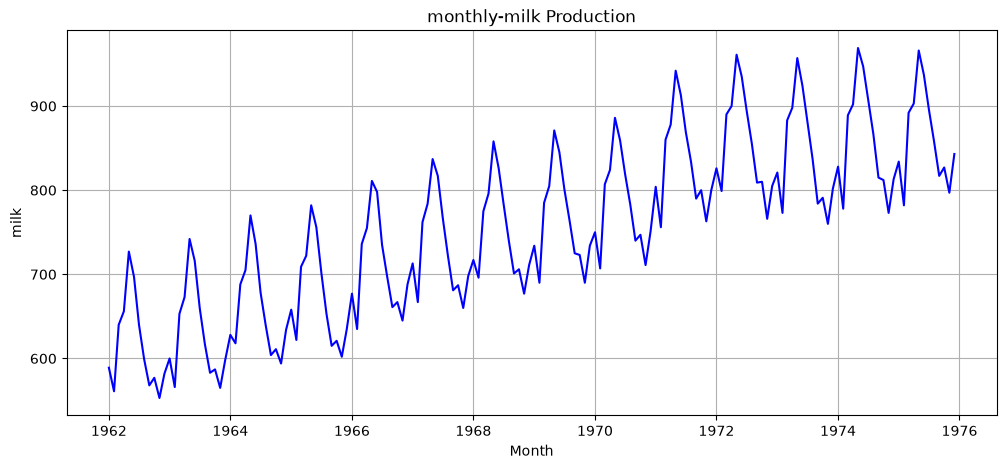

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df["Milk"],color="blue")
plt.title("monthly-milk Production")
plt.grid(True)
plt.xlabel("Month")
plt.ylabel("milk")


In [8]:
Series=df["Milk"]
result=seasonal_decompose(Series,model="additive",period=12)

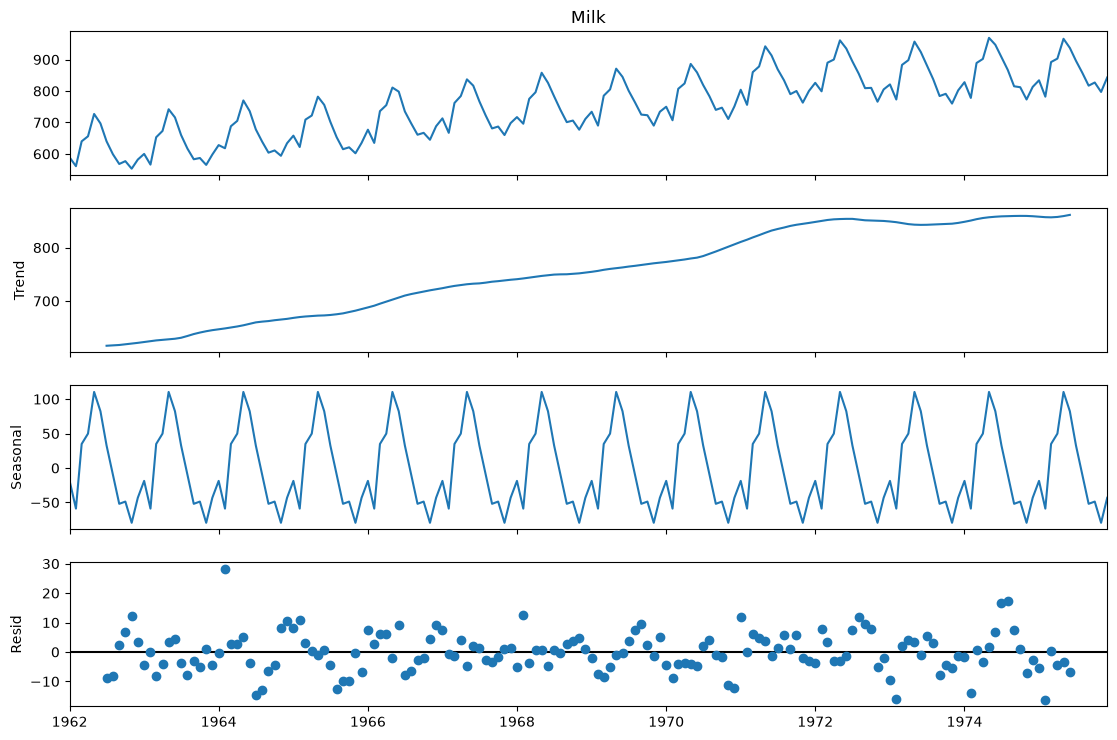

In [9]:
fighure=result.plot()
fighure.set_size_inches(12,8)
plt.show()

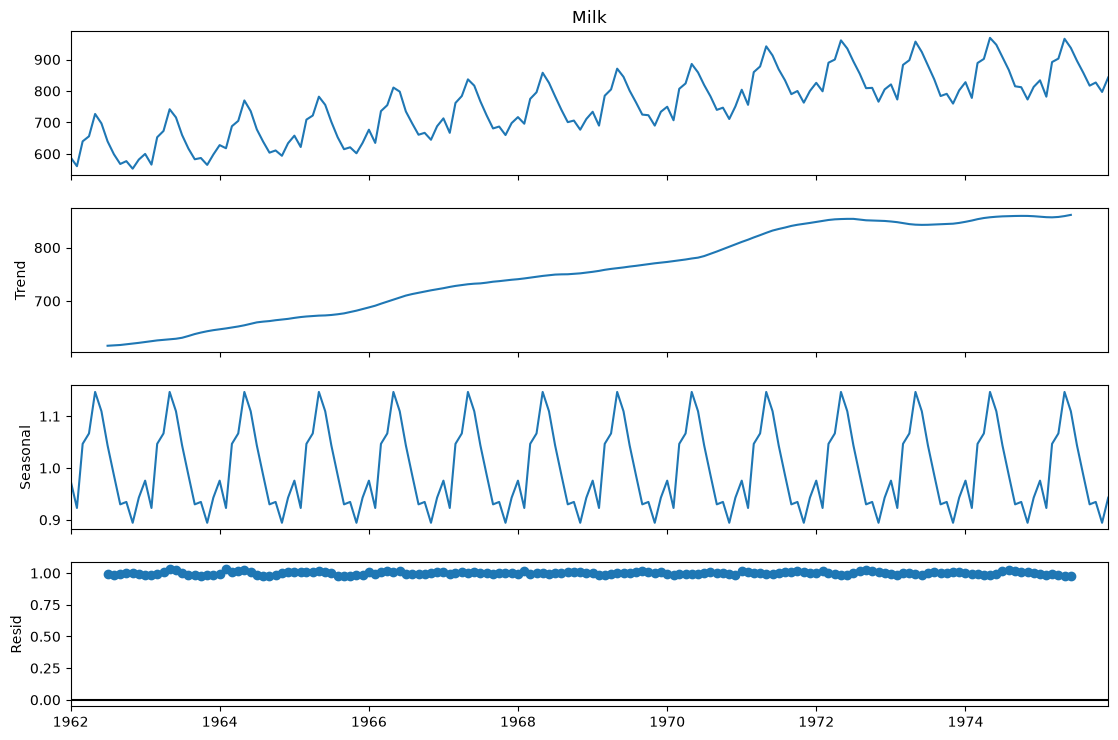

In [10]:
Series=df["Milk"]
result=seasonal_decompose(Series,model="multiplicative",period=12)
fighure=result.plot()
fighure.set_size_inches(12,8)
plt.show()

In [11]:
Y=df["Milk"]

m

In [12]:
focus=Y.rolling(window=3,center=True).mean()

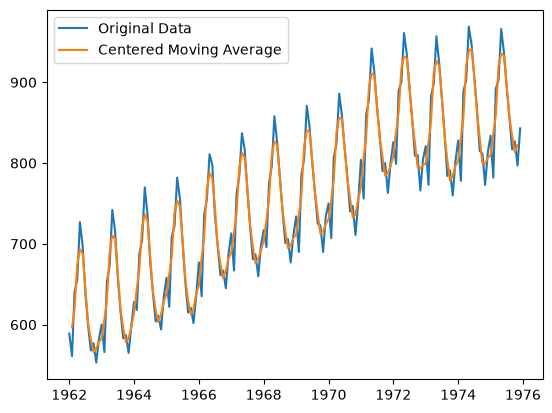

In [13]:
plt.plot(Y,label="Original Data")
plt.plot(focus,label="Centered Moving Average")
plt.legend()
plt.show()

In [14]:
# train test split
Y_train=df["Milk"].iloc[:-12]
Y_test=df["Milk"].iloc[-12:]

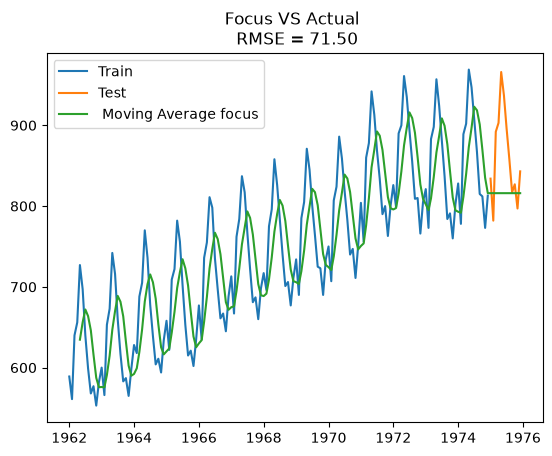

In [15]:
span=5
focus=Y_train.rolling(window=span).mean()
ma=focus.iloc[-1]
ma_series=pd.Series(ma.repeat(len(Y_test)),index=Y_test.index)
ma_focus=pd.concat([focus,ma_series])
rmse=root_mean_squared_error(Y_test,ma_series)
plt.plot(Y_train,label="Train")
plt.plot(Y_test,label="Test")
plt.plot(ma_focus,label=" Moving Average focus")
plt.title(f"Focus VS Actual \n RMSE = {rmse:.2f}")
plt.legend(loc="best")
plt.show()

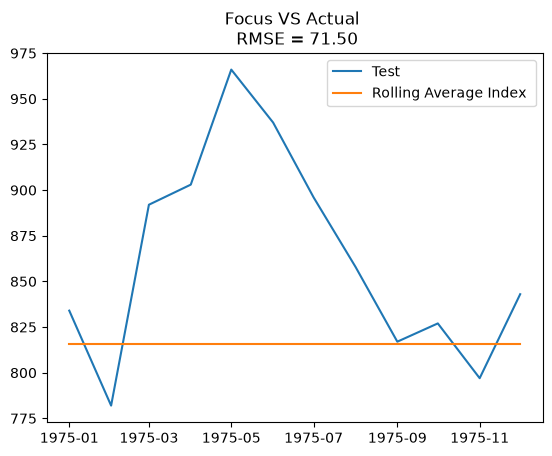

In [16]:
plt.plot(Y_test,label="Test")
ma_series.index=Y_test.index
plt.plot(ma_series,label="Rolling Average Index ")
plt.title(f"Focus VS Actual \n RMSE = {rmse:.2f}")
plt.legend(loc="best")
plt.show()

In [17]:
# simple ex smoothing
from statsmodels.tsa.api import SimpleExpSmoothing as sm


In [18]:
from statsmodels.tsa.api import SimpleExpSmoothing

alpha = 0.2

# Fit Simple Exponential Smoothing model
ses = SimpleExpSmoothing(Y_train)
sm_fit = ses.fit(smoothing_level=alpha)

focus = sm_fit.forecast(len(Y_test))

c:\Users\UserE\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\UserE\miniconda3\Lib\site-packages\pandas\util\_decorators.py:220: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


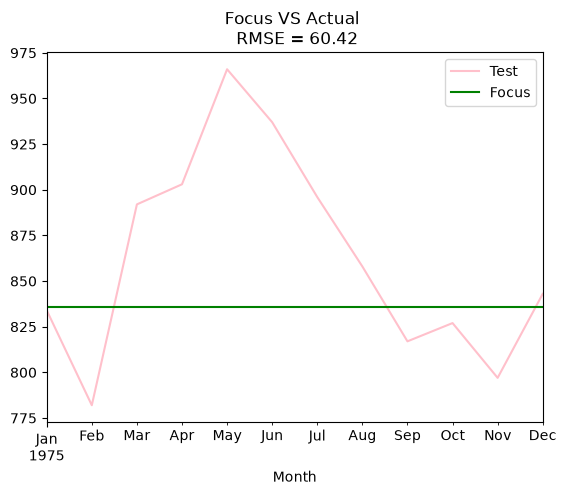

In [19]:
Y_test.plot(color="pink",label="Test")
focus.plot(color="green",label="Focus")
rmse=root_mean_squared_error(Y_test,focus)
plt.title(f"Focus VS Actual \n RMSE = {rmse:.2f}")
plt.legend(loc="best")
plt.show()

In [20]:
# Holt linear
from statsmodels.tsa.api import Holt

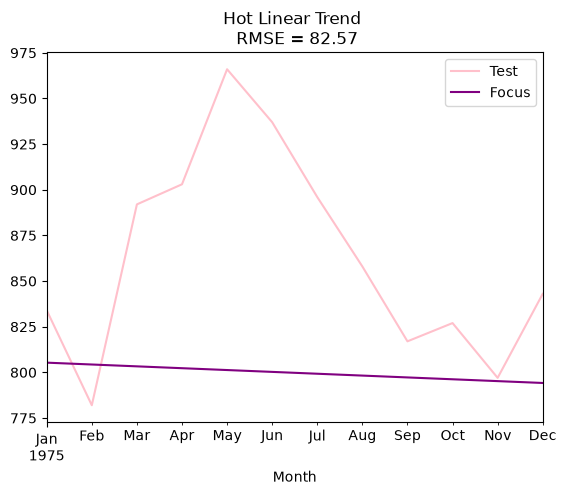

In [21]:
from statsmodels.tsa.api import Holt

# 1. (Optional) Explicitly assign frequency to prevent the ValueWarning
if hasattr(Y_train, "index") and Y_train.index.freq is None:
    Y_train = Y_train.asfreq("MS")

# Parameters
alpha, beta = 0.8, 0.02

# Fit Holt's model (level + trend) with manual smoothing parameters
holt = Holt(Y_train)
fit = holt.fit(smoothing_level=alpha, smoothing_trend=beta, optimized=False)

# Generate forecast matching test set length
forecast = fit.forecast(len(Y_test))
Y_test.plot(color="pink",label="Test")
forecast.plot(color="purple",label="Focus")
rmse=root_mean_squared_error(Y_test,forecast)
plt.title(f"Hot Linear Trend \n RMSE = {rmse:.2f}")
plt.legend(loc="best")
plt.show()

In [22]:
from ipywidgets import interact,widgets

In [23]:
from statsmodels.tsa.holtwinters import Holt
import ipywidgets as widgets
import matplotlib.pyplot as plt

holt = Holt(Y_train)

def hot_linear(alpha, belta):
    fit = holt.fit(
        smoothing_level=alpha,
        smoothing_trend=belta,
        optimized=False
    )

    forecast = fit.forecast(len(Y_test))

    plt.figure(figsize=(10,5))
    Y_test.plot(color="pink", label="Test")
    forecast.plot(color="purple", label="Forecast")

    rmse = root_mean_squared_error(Y_test, forecast)

    plt.title(
        f"Holt Linear Trend\nalpha={alpha:.2f}, beta={belta:.2f}, RMSE={rmse:.2f}"
    )
    plt.legend()
    plt.show()

interact(
        hot_linear,
        alpha=(0.01, 1.0, 0.01),
        belta=(0.01, 1.0, 0.01))



interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.hot_linear(alpha, belta)>

In [25]:
from statsmodels.tsa.holtwinters import Holt
import ipywidgets as widgets
import matplotlib.pyplot as plt

holt = Holt(Y_train, exponential=True)

def hot_linear(alpha, belta):
    fit = holt.fit(
        smoothing_level=alpha,
        smoothing_trend=belta,
        optimized=False
    )

    forecast = fit.forecast(len(Y_test))

    plt.figure(figsize=(10,5))
    Y_test.plot(color="pink", label="Test")
    forecast.plot(color="purple", label="Forecast")

    rmse = root_mean_squared_error(Y_test, forecast)

    plt.title(
        f"Holt Linear Trend\nalpha={alpha:.2f}, beta={belta:.2f}, RMSE={rmse:.2f}"
    )
    plt.legend()
    plt.show()

interact(
        hot_linear,
        alpha=(0.01, 1.0, 0.01),
        belta=(0.01, 1.0, 0.01))

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.hot_linear(alpha, belta)>

In [29]:
from statsmodels.tsa.holtwinters import Holt
from ipywidgets import interact
import matplotlib.pyplot as plt

def damped(alpha, belta, pi, Exponentiality, dampness):

    holt = Holt(
        Y_train,
        exponential=Exponentiality,
        damped_trend=dampness
    )

    fit = holt.fit(
        smoothing_level=alpha,
        smoothing_trend=belta,
        damping_trend=pi,
        optimized=False
    )

    forecast = fit.forecast(len(Y_test))

    plt.figure(figsize=(10,5))
    Y_test.plot(color="pink", label="Test")
    forecast.plot(color="purple", label="Forecast")

    rmse = root_mean_squared_error(Y_test, forecast)

    plt.title(
        f"Damped Trend\n"
        f"RMSE={rmse:.2f}, α={alpha:.2f}, β={belta:.2f}, φ={pi:.2f}"
    )

    plt.legend()
    plt.show()


interact(
    damped,
    alpha=(0.01, 1.0, 0.01),
    belta=(0.01, 1.0, 0.01),
    pi=(0.01, 1.0, 0.01),
    Exponentiality=[True, False],
    dampness=[True, False]
)

interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…

<function __main__.damped(alpha, belta, pi, Exponentiality, dampness)>

In [28]:
# triple ex smoothing =one winter
from statsmodels.tsa.api import ExponentialSmoothing
from ipywidgets import interact

def hw(alpha, belta, gemma, seasonality):

    model = ExponentialSmoothing(
        Y_train,
        trend="add",
        seasonal=seasonality,
        seasonal_periods=12
    )

    fit = model.fit(
        smoothing_level=alpha,
        smoothing_trend=belta,
        smoothing_seasonal=gemma,
        optimized=False
    )

    forecast = fit.forecast(len(Y_test))

    plt.figure(figsize=(10,5))
    Y_test.plot(color="pink", label="Test")
    forecast.plot(color="purple", label="Forecast")

    rmse = root_mean_squared_error(Y_test, forecast)

    plt.title(
        f"Holt-Winters\n"
        f"RMSE={rmse:.2f}, α={alpha:.2f}, β={belta:.2f}, γ={gemma:.2f}"
    )

    plt.legend()
    plt.show()


interact(
    hw,
    alpha=(0.01,1.0,0.01),
    belta=(0.01,1.0,0.01),
    gemma=(0.01,1.0,0.01),
    seasonality=["add","mul"]
);


interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, min=0.01, step=0.01), FloatSlider(v…